# Práctica 7

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys

sys.path.append('..')

from AI_algorithms.utils.plot import plot_decision_region_3d

Considere el siguiente conjunto de datos. Los atributos xi son atributos binarios y el atributo C es un
atributo de clase.

$$
\begin{array}{|c||c|c|c||c|}
\hline
 & x_1 & x_2 & x_3 & C \\
\hline
1 & 0 & 0 & 1 & 1 \\
2 & 0 & 0 & 0 & 0 \\
3 & 1 & 1 & 1 & 1 \\
4 & 0 & 1 & 1 & 0 \\
5 & 1 & 1 & 0 & 0 \\
6 & 0 & 1 & 0 & 1 \\
7 & 1 & 0 & 1 & 0 \\
8 & 1 & 0 & 0 & 1 \\
\hline
\end{array}
$$

In [2]:
X = np.array(
    [
        [0,0,1],
        [0,0,0],
        [1,1,1],
        [0,1,1],
        [1,1,0],
        [0,1,0],
        [1,0,1],
        [1,0,0]
    ]
)

y = np.array([1,0,1,0,0,1,0,1])

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (8, 3)
y.shape: (8,)


# Ejercicio 1

Considere la siguiente red neuronal:

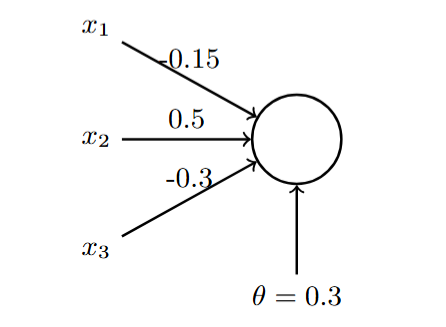

Con función de activación sigmoide

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

Calcule la matriz de confusión y diferentes métricas de desempeño.

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def predict(x,w,theta,activation=lambda x: x):
    z = np.dot(x, w.T) + theta
    return activation(z)

w = np.array([-0.15, 0.5, -0.3])
theta = 0.3
y_score = predict(X, w, theta, activation=sigmoid)
y_pred = np.where(y_score >= 0.5, 1, 0)

In [4]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.57      1.00      0.73         4

    accuracy                           0.62         8
   macro avg       0.79      0.62      0.56         8
weighted avg       0.79      0.62      0.56         8



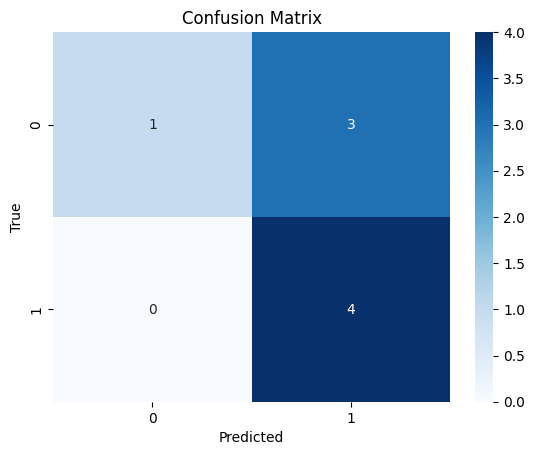

In [5]:
cmp = confusion_matrix(y, y_pred)

sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Vamos a graficar la region de decisión

In [6]:
plot_decision_region_3d(X, y,
                        pred_fun=lambda x: predict(x, w, theta, activation=sigmoid),
                        vmin=0.45, vmax=0.55,
                        title='Decision Boundary for model score',)

In [7]:
plot_decision_region_3d(X, y,
                        pred_fun=lambda x: np.round(predict(x, w, theta, activation=sigmoid)),
                        vmin=-0.1, vmax=1.1,
                        title='Decision Boundary for classification task',)

Como se puede ver en este diagrama, los datos no son linealmente separables

## Ejercicio 2

Entrene la red neuronal del punto anterior usando sklearn. Calcule m´etricas de desempeño sobre el conjunto de datos de entrenamiento. Discuta los resultados.

In [8]:
model = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X, y)
y_pred = model.predict(X)
print(f"Perceptron weights: {model.coef_}")
print("Perceptron bias (theta):", model.intercept_)
model

Perceptron weights: [[-1.  2.  0.]]
Perceptron bias (theta): [1.]


Perceptron(random_state=42)

In [9]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.50      0.75      0.60         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.47         8
weighted avg       0.50      0.50      0.47         8



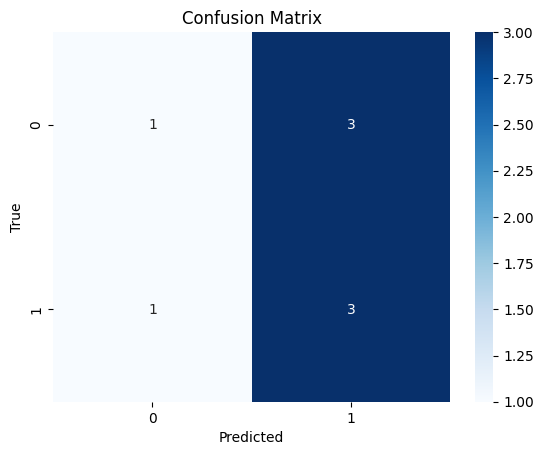

In [10]:
cmp = confusion_matrix(y, y_pred)

sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Incluso en este escenario donde se entrenaron los pesos, el modelo no dio mejores resultados, vamos a visualizar la nueva frontera de decisión

In [11]:
plot_decision_region_3d(X, y,
                        pred_fun=lambda x : model.predict(x[np.newaxis, :]),
                        vmin=-0.1, vmax=1.1,
                        title='Decision Boundary for model score',)

Vemos el mismo problema de los datos no linealmente separables

## Ejercicio 3

Diseñe una red neuronal que sea capaz de predecir el conjunto de entrenamiento con 0 error y entrénela usando `sklearn`. Discuta los resultados.

In [12]:
model = MLPClassifier(hidden_layer_sizes=(7,),
                      max_iter=1000,
                      random_state=42,
                      solver='adam',
                      activation='relu',
                      learning_rate_init=0.01)
model.fit(X, y)
y_pred = model.predict(X)
model

MLPClassifier(hidden_layer_sizes=(7,), learning_rate_init=0.01, max_iter=1000,
              random_state=42)

In [13]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



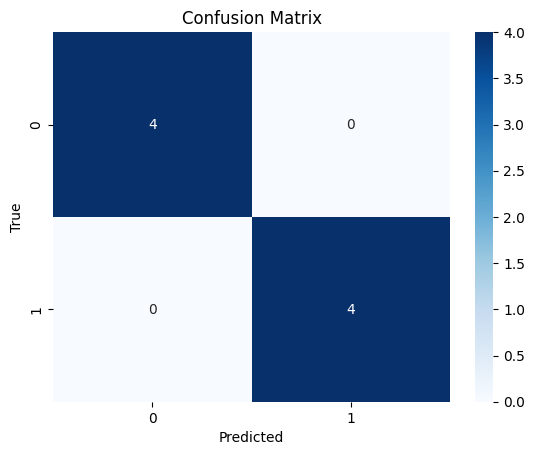

In [14]:
cmp = confusion_matrix(y, y_pred)

sns.heatmap(cmp, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Finalmente vamos a visualizar la frontera de decisión de este escenario

In [15]:
plot_decision_region_3d(X, y,
                        pred_fun=lambda x : model.predict(x[np.newaxis, :]),
                        vmin=-0.1, vmax=1.1,
                        title='Decision Boundary for model score',)